In [422]:
#first pandas code

import pandas as pd
import numpy as np



In [423]:
# synthetic data



data = {
    'OrderID': list(range(1, 21)),
    'CustomerID': [101, 102, 101, 103, 104, 105, 102, 101, 103, 106,
                   107, None, 101, 'unknown', 110, 102, 104, 108, 111, 103],
    'CustomerName': ['Alice Johnson', 'Bob Smith', 'alice johnson', 'Charlie Zhang', 'Diana Prince', 
                     'Eve Adams', 'BOB SMITH', 'ALICE JOHNSON', 'charlie zhang', 'Frank Castle',
                     'Grace Hopper', None, 'A. Johnson', 'unknown', 'Diana P.', 
                     'Bob smith', 'Diana Prince', 12345, 'Henry Ford', 'Charlie Z.'],
    'Product': ['Laptop', 'mouse', 'Monitor', 'Keyboard', 'Laptop', 'Mouse', 'Monitor', 'laptop', 'KeyBoard', 'Mouse',
                'keyboard', 'Laptop', 'Mouse', 'Monitor', 'Laptop', 'KEYBOARD', None, 'Monitor', 'Laptop', 'Mouse'],
    'Quantity': [1, 2, 1, 1, 1, 3, 1, 2, 2, 1,
                 'two', -1, 3, 1, 0, 3, 2, 1, 1, np.nan],
    'Price': [1200, 25, 250, 75, 1200, 25, 250, 1200, 75, 25,
              75, 1300, None, 275, 'free', 75, 25, 260, 1350, 25],
    'ShippingDate': pd.to_datetime([
        '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08', '2025-01-09',
        '2025-01-10', '2025-01-11', '2025-01-12', '2025-01-13', '2025-01-14',
        '2025-01-15', '2025-01-16', '2025-13-17',  # invalid date
        '2026-01-18', '2010-01-19', '2025-01-20', None, '2025-01-22', '2025-01-23', 'not available'
    ], errors='coerce'),
    'Discount': [0.1, 0.05, 0.1, 0, 0.1, 0, 0.05, 0.15, 0.1, 0,
                 None, '0.2', 0, 0.1, 0.15, 0, 0.05, 'ten', 0.2, 0]
}







In [424]:
# load data 
sales_data_df = pd.DataFrame(data)

sales_data_df.set_index('OrderID', inplace=True)

# show first/last rows

sales_data_df.tail()

# get info

sales_data_df.info()


sales_data_df.describe()






<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 1 to 20
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CustomerID    19 non-null     object        
 1   CustomerName  19 non-null     object        
 2   Product       19 non-null     object        
 3   Quantity      19 non-null     object        
 4   Price         19 non-null     object        
 5   ShippingDate  17 non-null     datetime64[ns]
 6   Discount      19 non-null     object        
dtypes: datetime64[ns](1), object(6)
memory usage: 1.2+ KB


,ShippingDate
count,17
mean,2024-03-18 14:07:03.529411840
min,2010-01-19 00:00:00
25%,2025-01-08 00:00:00
50%,2025-01-12 00:00:00
75%,2025-01-16 00:00:00
max,2026-01-18 00:00:00


In [425]:
# indesxing, selecting and filtering data

# select a column

sales_data_df['CustomerID'].head()
# ALT 
# sales_data_df.CustomerID.head()

# select multiple columns
sales_data_df[['CustomerID','Price','Discount','CustomerName']]




,CustomerID,Price,Discount,CustomerName
OrderID,,,,
1,101,1200,0.1,Alice Johnson
2,102,25,0.05,Bob Smith
3,101,250,0.1,alice johnson
4,103,75,0,Charlie Zhang
5,104,1200,0.1,Diana Prince
6,105,25,0,Eve Adams
7,102,250,0.05,BOB SMITH
8,101,1200,0.15,ALICE JOHNSON
9,103,75,0.1,charlie zhang


#### Loc vs iloc

Are used for selecting dataframes and series.

#### .loc (Label based slicing)
- selects data based on labels of index and columns
- end label is inclusive
- can be used with boolean arrays for conditional selection
- Raises keyerror if label is not found
-allows for adding new rows and columns by assigning values to labels

##### syntax

df.loc[row_indexer, column_index]


#### .iloc (Integer-location based indexing)
- slects data based on integer positions (from 0 to length-1) of the rows and columns
- the end position is not inclusive, similar to python
- Raises index error if out of bounds position is accessed

#### syntax
df.iloc[row_indexer, column_index]



In [426]:
# loc examples

# 1. by row label
sales_data_df.loc[1]

# multiple
sales_data_df.loc[[1,2,19]]




# 2. row + column

sales_data_df.head()
len = sales_data_df.shape[0]

sales_data_df.loc[[1,10,19],['CustomerName','Price']]

# Row slice. Includes last item
sales_data_df.loc[1:3]

# all rows, specific product

sales_data_df.loc[:,['Product','CustomerName']]

# boolean indexing

# select all orders from particular people
sales_data_df.loc[(sales_data_df['Product'] != 'laptop') | (sales_data_df['Product'] != 'Mouse')]

sales_data_df.tail()






,CustomerID,CustomerName,Product,Quantity,Price,ShippingDate,Discount
OrderID,,,,,,,
16,102,Bob smith,KEYBOARD,3,75,2025-01-20,0
17,104,Diana Prince,None,2,25,NaT,0.05
18,108,12345,Monitor,1,260,2025-01-22,ten
19,111,Henry Ford,Laptop,1,1350,2025-01-23,0.2
20,103,Charlie Z.,Mouse,NaN,25,NaT,0


In [427]:
# iloc examples

# row by index location

sales_data_df.head()

sales_data_df.iloc[[1,19]]

# row + column by index positions



sales_data_df.iloc[[0,1]] #multiple

sales_data_df.head()

# row + column by index positions

sales_data_df.iloc[19,2] #prints row index 19, column index 2

sales_data_df.iloc[[19,2]] # prints row 19,2

# slicee

sales_data_df.iloc[0:3]  #unlike loc, last item is exlusive here

# rows + coluns

sales_data_df.iloc[[0,3],[2,3]] #prints rows index 0,3 and cols index 2,3


# all rows, spoecific cols indexes

sales_data_df.iloc[:5,[2,3]]

# last row using the negative index

sales_data_df.iloc[[-2,-3]]









,CustomerID,CustomerName,Product,Quantity,Price,ShippingDate,Discount
OrderID,,,,,,,
19,111,Henry Ford,Laptop,1,1350,2025-01-23,0.2
18,108,12345,Monitor,1,260,2025-01-22,ten


### EDA

In [428]:
sales_data_df.head()




,CustomerID,CustomerName,Product,Quantity,Price,ShippingDate,Discount
OrderID,,,,,,,
1,101,Alice Johnson,Laptop,1,1200,2025-01-05,0.1
2,102,Bob Smith,mouse,2,25,2025-01-06,0.05
3,101,alice johnson,Monitor,1,250,2025-01-07,0.1
4,103,Charlie Zhang,Keyboard,1,75,2025-01-08,0
5,104,Diana Prince,Laptop,1,1200,2025-01-09,0.1


In [429]:
sales_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20 entries, 1 to 20
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   CustomerID    19 non-null     object        
 1   CustomerName  19 non-null     object        
 2   Product       19 non-null     object        
 3   Quantity      19 non-null     object        
 4   Price         19 non-null     object        
 5   ShippingDate  17 non-null     datetime64[ns]
 6   Discount      19 non-null     object        
dtypes: datetime64[ns](1), object(6)
memory usage: 1.8+ KB


In [430]:
# conver customer id into numeric and drop invalid ones

sales_data_df['CustomerID'] = pd.to_numeric(sales_data_df['CustomerID'], errors='coerce')
sales_data_df = sales_data_df.dropna(subset=['CustomerID'])
sales_data_df['CustomerID'] = sales_data_df['CustomerID'].astype(int)

# standardize customer name (title case, drop numeric)

sales_data_df['CustomerName'] = sales_data_df['CustomerName'].astype(str)

# clean quantity and price


sales_data_df['Quantity'] = pd.to_numeric(sales_data_df['Quantity'], errors='coerce')
sales_data_df['Price'] = pd.to_numeric(sales_data_df['Price'], errors='coerce')

# filter out rows with missing or invalid qty/price

sales_data_df = sales_data_df[(sales_data_df['Quantity'] > 0) & (sales_data_df['Price'] > 0)]

# clean products column

sales_data_df['Product'] = sales_data_df['Product'].str.strip().str.lower()

# clean shipping date

sales_data_df['ShippingDate'] = pd.to_datetime(sales_data_df['ShippingDate'], errors='coerce')
sales_data_df = sales_data_df.dropna(subset=['ShippingDate'])
sales_data_df

# clean discount
sales_data_df['Discount'] = pd.to_numeric(sales_data_df['Discount'], errors='coerce')
sales_data_df = sales_data_df.dropna(subset=['Discount'])

sales_data_df

,CustomerID,CustomerName,Product,Quantity,Price,ShippingDate,Discount
OrderID,,,,,,,
1,101,Alice Johnson,laptop,1.0,1200.0,2025-01-05,0.10
2,102,Bob Smith,mouse,2.0,25.0,2025-01-06,0.05
3,101,alice johnson,monitor,1.0,250.0,2025-01-07,0.10
4,103,Charlie Zhang,keyboard,1.0,75.0,2025-01-08,0.00
5,104,Diana Prince,laptop,1.0,1200.0,2025-01-09,0.10
6,105,Eve Adams,mouse,3.0,25.0,2025-01-10,0.00
7,102,BOB SMITH,monitor,1.0,250.0,2025-01-11,0.05
8,101,ALICE JOHNSON,laptop,2.0,1200.0,2025-01-12,0.15
9,103,charlie zhang,keyboard,2.0,75.0,2025-01-13,0.10


In [431]:
# calaculated column

sales_data_df['Total'] = sales_data_df['Price'] * sales_data_df['Quantity'] * (1-sales_data_df['Discount'])

sales_data_df['Tax'] = sales_data_df['Discount'] * 1.5

# total with tax

sales_data_df['TotalInclisiveTax'] = sales_data_df['Total'] * (1+ sales_data_df['Tax'])

# drop column

sales_data_df.drop('Total',axis=1)

,CustomerID,CustomerName,Product,Quantity,Price,ShippingDate,Discount,Tax,TotalInclisiveTax
OrderID,,,,,,,,,
1,101,Alice Johnson,laptop,1.0,1200.0,2025-01-05,0.10,0.150,1242.0000
2,102,Bob Smith,mouse,2.0,25.0,2025-01-06,0.05,0.075,51.0625
3,101,alice johnson,monitor,1.0,250.0,2025-01-07,0.10,0.150,258.7500
4,103,Charlie Zhang,keyboard,1.0,75.0,2025-01-08,0.00,0.000,75.0000
5,104,Diana Prince,laptop,1.0,1200.0,2025-01-09,0.10,0.150,1242.0000
6,105,Eve Adams,mouse,3.0,25.0,2025-01-10,0.00,0.000,75.0000
7,102,BOB SMITH,monitor,1.0,250.0,2025-01-11,0.05,0.075,255.3125
8,101,ALICE JOHNSON,laptop,2.0,1200.0,2025-01-12,0.15,0.225,2499.0000
9,103,charlie zhang,keyboard,2.0,75.0,2025-01-13,0.10,0.150,155.2500


In [432]:
# Cheat sheet

# rename a column
sales_data_df.rename(columns={"ShippingDate": "DeliverDate"}, inplace=True)
import random
sales_data_df['TaxFee'] = sales_data_df['Tax'] * random.randint(1,9)

sales_data_df

# total with tax

sales_data_df['TotalInclisiveTax'] = sales_data_df['Total'] * (1+ sales_data_df['Tax'])

# drop column

sales_data_df.drop('Total',axis=1)

sales_data_df.drop(1, axis=0)






,CustomerID,CustomerName,Product,Quantity,Price,DeliverDate,Discount,Total,Tax,TotalInclisiveTax,TaxFee
OrderID,,,,,,,,,,,
2,102,Bob Smith,mouse,2.0,25.0,2025-01-06,0.05,47.5,0.075,51.0625,0.3
3,101,alice johnson,monitor,1.0,250.0,2025-01-07,0.10,225.0,0.150,258.7500,0.6
4,103,Charlie Zhang,keyboard,1.0,75.0,2025-01-08,0.00,75.0,0.000,75.0000,0.0
5,104,Diana Prince,laptop,1.0,1200.0,2025-01-09,0.10,1080.0,0.150,1242.0000,0.6
6,105,Eve Adams,mouse,3.0,25.0,2025-01-10,0.00,75.0,0.000,75.0000,0.0
7,102,BOB SMITH,monitor,1.0,250.0,2025-01-11,0.05,237.5,0.075,255.3125,0.3
8,101,ALICE JOHNSON,laptop,2.0,1200.0,2025-01-12,0.15,2040.0,0.225,2499.0000,0.9
9,103,charlie zhang,keyboard,2.0,75.0,2025-01-13,0.10,135.0,0.150,155.2500,0.6
10,106,Frank Castle,mouse,1.0,25.0,2025-01-14,0.00,25.0,0.000,25.0000,0.0


In [473]:
# expensive products

expensive_prod = sales_data_df[sales_data_df['Price']>100].Product

# orders with quantity > 1 AND a discount

discounted_orders = sales_data_df[(sales_data_df['Quantity']>1) & sales_data_df['Discount']> 0]
discounted_orders


# apply

# shipping category
func = lambda x: 'High' if x >1000 else 'Low'
sales_data_df['ShipingCategory'] = sales_data_df['TotalInclisiveTax'].apply(func)
sales_data_df

,CustomerID,CustomerName,Product,Quantity,Price,DeliverDate,Discount,Total,Tax,TotalInclisiveTax,TaxFee,ShipingCategory
OrderID,,,,,,,,,,,,
1,101,Alice Johnson,laptop,1.0,1200.0,2025-01-05,0.10,1080.0,0.150,1242.0000,0.6,High
2,102,Bob Smith,mouse,2.0,25.0,2025-01-06,0.05,47.5,0.075,51.0625,0.3,Low
3,101,alice johnson,monitor,1.0,250.0,2025-01-07,0.10,225.0,0.150,258.7500,0.6,Low
4,103,Charlie Zhang,keyboard,1.0,75.0,2025-01-08,0.00,75.0,0.000,75.0000,0.0,Low
5,104,Diana Prince,laptop,1.0,1200.0,2025-01-09,0.10,1080.0,0.150,1242.0000,0.6,High
6,105,Eve Adams,mouse,3.0,25.0,2025-01-10,0.00,75.0,0.000,75.0000,0.0,Low
7,102,BOB SMITH,monitor,1.0,250.0,2025-01-11,0.05,237.5,0.075,255.3125,0.3,Low
8,101,ALICE JOHNSON,laptop,2.0,1200.0,2025-01-12,0.15,2040.0,0.225,2499.0000,0.9,High
9,103,charlie zhang,keyboard,2.0,75.0,2025-01-13,0.10,135.0,0.150,155.2500,0.6,Low


#### Handling missing data


- Check for missing values	df.isnull() or df.isna()	Returns a boolean DataFrame.
- Get counts of missing values	df.isnull().sum()	The .sum() gives a count per column.
- Drop rows with missing values	df.dropna()	Default drops rows. axis=1 drops columns.
- Fill missing values	df.fillna(value)	Can be a single value, a column's mean/median, etc.

In [474]:
sales_data_df.isnull().sum()

CustomerID           0
CustomerName         0
Product              0
Quantity             0
Price                0
DeliverDate          0
Discount             0
Total                0
Tax                  0
TotalInclisiveTax    0
TaxFee               0
ShipingCategory      0
dtype: int64

### Grouping/ Aggregating Data

In [490]:
# Find the total quantity sold for each product


product_sales = sales_data_df.groupby("Product")['Quantity'].sum().reset_index()
print(f"Product sales:\n]n {product_sales}")

# average total spending per customer

customer_spend = sales_data_df.groupby(['CustomerID'])['TotalInclisiveTax'].sum().reindex()
print(f"Avg customer spend:\n\n {round(customer_spend,1)}")



Product sales:
]n     Product  Quantity
0  keyboard       6.0
1    laptop       5.0
2   monitor       2.0
3     mouse       6.0
Avg customer spend:

 CustomerID
101    3999.8
102     531.4
103     230.2
104    1242.0
105      75.0
106      25.0
111    1404.0
Name: TotalInclisiveTax, dtype: float64


In [492]:
# use Agg. to get multiple stats once

customer_stats = sales_data_df.groupby('CustomerID').agg(
    total_orders = ('CustomerID', 'count'),#should have been order id
    total_spent = ('Total','sum'),
    avg_discount=('Discount','mean')
).reset_index()

print(f"\nCustomer Statisics:\n\n {customer_stats}")



Customer Statisics:

    CustomerID  total_orders  total_spent  avg_discount
0         101             3       3345.0      0.116667
1         102             3        510.0      0.033333
2         103             2        210.0      0.050000
3         104             1       1080.0      0.100000
4         105             1         75.0      0.000000
5         106             1         25.0      0.000000
6         111             1       1080.0      0.200000


### Merge Data frames

Join based on a key	pd.merge(df1, df2, on='key')	SQL-like joins: how='inner', left, right, outer.
Stack DataFrames	pd.concat([df1, df2])	Concatenates along an axis.

In [500]:
copy_sales_df = sales_data_df[:].copy()
copy_sales_df

customer_data = {
    'CustomerID': [101, 102, 103, 104, 105, 106, 107],
    'CustomerName': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace']
}

customer_df = pd.DataFrame(customer_data)

merged_df = pd.merge(copy_sales_df, customer_df, on='CustomerID', how='left')


print("Merged sales and customer data:")
print(merged_df.head())



Merged sales and customer data:
   CustomerID CustomerName_x   Product  Quantity   Price DeliverDate  \
0         101  Alice Johnson    laptop       1.0  1200.0  2025-01-05   
1         102      Bob Smith     mouse       2.0    25.0  2025-01-06   
2         101  alice johnson   monitor       1.0   250.0  2025-01-07   
3         103  Charlie Zhang  keyboard       1.0    75.0  2025-01-08   
4         104   Diana Prince    laptop       1.0  1200.0  2025-01-09   

   Discount   Total    Tax  TotalInclisiveTax  TaxFee ShipingCategory  \
0      0.10  1080.0  0.150          1242.0000     0.6            High   
1      0.05    47.5  0.075            51.0625     0.3             Low   
2      0.10   225.0  0.150           258.7500     0.6             Low   
3      0.00    75.0  0.000            75.0000     0.0             Low   
4      0.10  1080.0  0.150          1242.0000     0.6            High   

  CustomerName_y  
0          Alice  
1            Bob  
2          Alice  
3        Charlie  
4

In [501]:
# top 5 most bought products

sales_data_df

,CustomerID,CustomerName,Product,Quantity,Price,DeliverDate,Discount,Total,Tax,TotalInclisiveTax,TaxFee,ShipingCategory
OrderID,,,,,,,,,,,,
1,101,Alice Johnson,laptop,1.0,1200.0,2025-01-05,0.10,1080.0,0.150,1242.0000,0.6,High
2,102,Bob Smith,mouse,2.0,25.0,2025-01-06,0.05,47.5,0.075,51.0625,0.3,Low
3,101,alice johnson,monitor,1.0,250.0,2025-01-07,0.10,225.0,0.150,258.7500,0.6,Low
4,103,Charlie Zhang,keyboard,1.0,75.0,2025-01-08,0.00,75.0,0.000,75.0000,0.0,Low
5,104,Diana Prince,laptop,1.0,1200.0,2025-01-09,0.10,1080.0,0.150,1242.0000,0.6,High
6,105,Eve Adams,mouse,3.0,25.0,2025-01-10,0.00,75.0,0.000,75.0000,0.0,Low
7,102,BOB SMITH,monitor,1.0,250.0,2025-01-11,0.05,237.5,0.075,255.3125,0.3,Low
8,101,ALICE JOHNSON,laptop,2.0,1200.0,2025-01-12,0.15,2040.0,0.225,2499.0000,0.9,High
9,103,charlie zhang,keyboard,2.0,75.0,2025-01-13,0.10,135.0,0.150,155.2500,0.6,Low


In [509]:
top_sold_products = sales_data_df.groupby('Product').agg(
    total_qty = ('Quantity','sum'),
    sales_amount = ('Total','sum'),
    avg_discount = ('Discount','mean')

).reset_index().sort_values(by='total_qty', ascending=False)

top_sold_products


,Product,total_qty,sales_amount,avg_discount
0,keyboard,6.0,435.0,0.033333
3,mouse,6.0,147.5,0.016667
1,laptop,5.0,5280.0,0.137500
2,monitor,2.0,462.5,0.075000


### Time Series moving average and cumulative average

In [558]:
sales_data_df

,CustomerID,CustomerName,Product,Quantity,Price,Discount,Total,Tax,TotalInclisiveTax,TaxFee,ShipingCategory,Product_3D_MA
DeliverDate,,,,,,,,,,,,
2025-01-05,101,Alice Johnson,laptop,1.0,1200.0,0.10,1080.0,0.150,1242.0000,0.6,High,135.0
2025-01-06,102,Bob Smith,mouse,2.0,25.0,0.05,47.5,0.075,51.0625,0.3,Low,225.0
2025-01-07,101,alice johnson,monitor,1.0,250.0,0.10,225.0,0.150,258.7500,0.6,Low,1080.0
2025-01-08,103,Charlie Zhang,keyboard,1.0,75.0,0.00,75.0,0.000,75.0000,0.0,Low,1080.0
2025-01-09,104,Diana Prince,laptop,1.0,1200.0,0.10,1080.0,0.150,1242.0000,0.6,High,2040.0
2025-01-10,105,Eve Adams,mouse,3.0,25.0,0.00,75.0,0.000,75.0000,0.0,Low,1080.0
2025-01-11,102,BOB SMITH,monitor,1.0,250.0,0.05,237.5,0.075,255.3125,0.3,Low,225.0
2025-01-12,101,ALICE JOHNSON,laptop,2.0,1200.0,0.15,2040.0,0.225,2499.0000,0.9,High,237.5
2025-01-13,103,charlie zhang,keyboard,2.0,75.0,0.10,135.0,0.150,155.2500,0.6,Low,47.5


In [561]:
# moving average on delivery dates

# set shipping date as index and sort

sales_data_df = sales_data_df.sort_values('DeliverDate')



In [565]:
daily_sales = sales_data_df['Total'].resample('D').sum()

daily_sales

DeliverDate
2025-01-05    1080.0
2025-01-06      47.5
2025-01-07     225.0
2025-01-08      75.0
2025-01-09    1080.0
2025-01-10      75.0
2025-01-11     237.5
2025-01-12    2040.0
2025-01-13     135.0
2025-01-14      25.0
2025-01-15       0.0
2025-01-16       0.0
2025-01-17       0.0
2025-01-18       0.0
2025-01-19       0.0
2025-01-20     225.0
2025-01-21       0.0
2025-01-22       0.0
2025-01-23    1080.0
Freq: D, Name: Total, dtype: float64

In [567]:
daily_sales_ma = daily_sales.rolling(window=3).mean()
daily_sales_ma

DeliverDate
2025-01-05           NaN
2025-01-06           NaN
2025-01-07    450.833333
2025-01-08    115.833333
2025-01-09    460.000000
2025-01-10    410.000000
2025-01-11    464.166667
2025-01-12    784.166667
2025-01-13    804.166667
2025-01-14    733.333333
2025-01-15     53.333333
2025-01-16      8.333333
2025-01-17      0.000000
2025-01-18      0.000000
2025-01-19      0.000000
2025-01-20     75.000000
2025-01-21     75.000000
2025-01-22     75.000000
2025-01-23    360.000000
Freq: D, Name: Total, dtype: float64

In [569]:
sales_summary = pd.DataFrame({
    'Daily Sales' : daily_sales,
    '3D_MA': daily_sales_ma
})
sales_summary

,Daily Sales,3D_MA
DeliverDate,,
2025-01-05,1080.0,NaN
2025-01-06,47.5,NaN
2025-01-07,225.0,450.833333
2025-01-08,75.0,115.833333
2025-01-09,1080.0,460.000000
2025-01-10,75.0,410.000000
2025-01-11,237.5,464.166667
2025-01-12,2040.0,784.166667
2025-01-13,135.0,804.166667


In [577]:
orders_sold_daily = sales_data_df['Quantity'].resample('D').sum()
orders_sold_daily

orders_3D_ma = orders_sold_daily.rolling(window=3).mean()
orders_3D_ma

orders_summary = pd.DataFrame({
    "daily_orders": orders_sold_daily,
    "3d_orders_avg": orders_3D_ma

})

orders_summary

,daily_orders,3d_orders_avg
DeliverDate,,
2025-01-05,1.0,NaN
2025-01-06,2.0,NaN
2025-01-07,1.0,1.333333
2025-01-08,1.0,1.333333
2025-01-09,1.0,1.000000
2025-01-10,3.0,1.666667
2025-01-11,1.0,1.666667
2025-01-12,2.0,2.000000
2025-01-13,2.0,1.666667


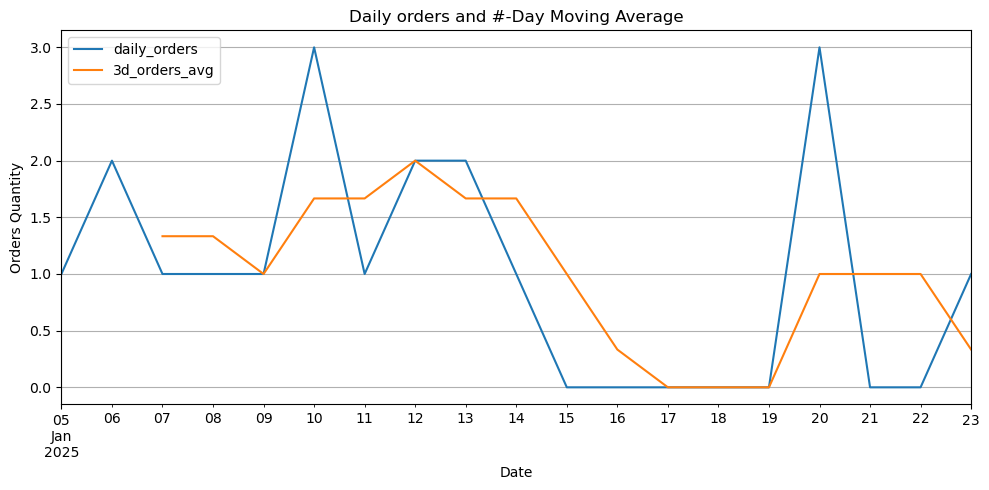

In [578]:
import matplotlib.pyplot as plt
orders_summary.plot(figsize=(10,5), title='Daily orders and #-Day Moving Average')

plt.ylabel('Orders Quantity')
plt.xlabel('Date')

plt.grid(True)
plt.tight_layout()
plt.show()